# Fermi Surface Visualization   
**by <span style="color:darkgreen">Jan Stutz</span>, <span style="color:darkgreen">Dmitrii Nabok</span> & <span style="color:darkgreen">Caterina Cocchi</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial, it will be shown how you can use **`exciting`** to calculate and visualize the Fermi surface of gold.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**
    
[0. Before Starting](#0)
    
[1. Fermi Surface 3D Plot](#1)  
      
   - [Exercise](#2)

</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

As a first step, you may create a running directory for the notebook.

In [ ]:
%%bash -l
mkdir -p run_tutorial_fermi_surface

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Fermi Surface 3D Plot</span>

A general input file for generating the Fermi surface of gold should look like this:

<span class="FERMI_SURFACE"></span>
```xml
<input>
 
   <title>Gold</title>
 
   <structure speciespath="$EXCITINGROOT/species" autormt="true">
      <crystal scale="7.707">
         <basevect> 0.5  0.5  0.0 </basevect>
         <basevect> 0.5  0.0  0.5 </basevect>
         <basevect> 0.0  0.5  0.5 </basevect>
      </crystal>
      <species speciesfile="Au.xml">
         <atom coord="0.0 0.0 0.0"/>
      </species>
   </structure>
 
   <groundstate 
      do="fromscratch"
      xctype="GGA_PBE_SOL"
      rgkmax="8.0" 
      ngridk="8 8 8"
      nempty="10"
      stype="Methfessel-Paxton 1"
      swidth="0.01"
      >
   </groundstate>
 
   <properties>
      <fermisurfaceplot nstfsp="6">
         <plot3d>
            <box grid="40 40 40" >
               <origin coord="0 0 0"/>
               <point  coord="1 0 0"/>
               <point  coord="0 1 0"/>
               <point  coord="0 0 1"/>
            </box>
         </plot3d>
      </fermisurfaceplot>
   </properties>
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("fermi_surface_visualization", "FERMI_SURFACE")

# Write out the input as an XML file:
with open('./run_tutorial_fermi_surface/input.xml', "w") as fid:
    fid.write(input_str)

To perform the actual calculation, make sure to set **$EXCITINGROOT** to the correct **`exciting`** root directory in the <code><span style="color:mediumblue">speciespath</span></code> attribute using the command

In [ ]:
%%bash -l
cd run_tutorial_fermi_surface
python3 -m excitingscripts.setup.excitingroot
cd ..

Assuming that you are already familiar with the <code><span style="color:green">groundstate</span></code> block in the input file, we now focus on the <code><span style="color:green">properties</span></code> block:

```xml
...
   <properties>
      <fermisurfaceplot nstfsp="6">
         <plot3d>
            <box grid="40 40 40" >
               <origin coord="0 0 0"/>
               <point  coord="1 0 0"/>
               <point  coord="0 1 0"/>
               <point  coord="0 0 1"/>
            </box>
         </plot3d>
      </fermisurfaceplot>
   </properties>
...
```

The element <code><span style="color:green">fermisurfaceplot</span></code> triggers the calculation of the Fermi surface. The value of the attribute <code><span style="color:mediumblue">nstfsp</span></code> indicates the number of bands which are considered to compute the Fermi surface. In this case we choose **6**, which also corresponds to the default value for this attribute (see **[Input Reference](https://www.exciting-code.org/home/about/input-reference)**). By specifying the element <code><span style="color:green">plot3d</span></code> we are generating a 3D representation of the Fermi surface. For a complete description of the functionality of this element and of its sub-elements refer to the tutorial **How to visualize Kohn-Sham states**.

Now you can start the calculation by executing the following command.

In [ ]:
%%bash -l
cd run_tutorial_fermi_surface
python3 -m excitingscripts.execute.single
cd ..

An output file **FERMISURF.bxsf** is generated. This file is the input for the visualization with **FSvisual**. It should be installed already in the current environment, you can follow the instructions if you encounter problems.
<hr style="border:1px solid #DDD"> </hr>
<details>
   
<summary><strong><span style="color:firebrick">What to do if FSvisual is not yet installed</span></strong></summary>

If FSvisual is not installed in your current environment, you can execute the following command to install the latest version:
    
```bash
%%bash -l
pip install --upgrade fsvisual
```
</details>
<hr style="border:1px solid #DDD"> </hr>

*A more comprehensive installation guide can be found here: [FSvisual_github](https://github.com/exciting/FSvisual)*

In the directory of your exciting output files, type

In [ ]:
!fsvisual run_tutorial_fermi_surface/FERMISURF.bxsf

to visualize the created Fermi surface. Once the process is finished the visualization will directly open in the default browser. It will also be saved as an HTML file in your current directory so that one can reopen the visualization after closing the browser tab.

The result should look like the image below:

<img src="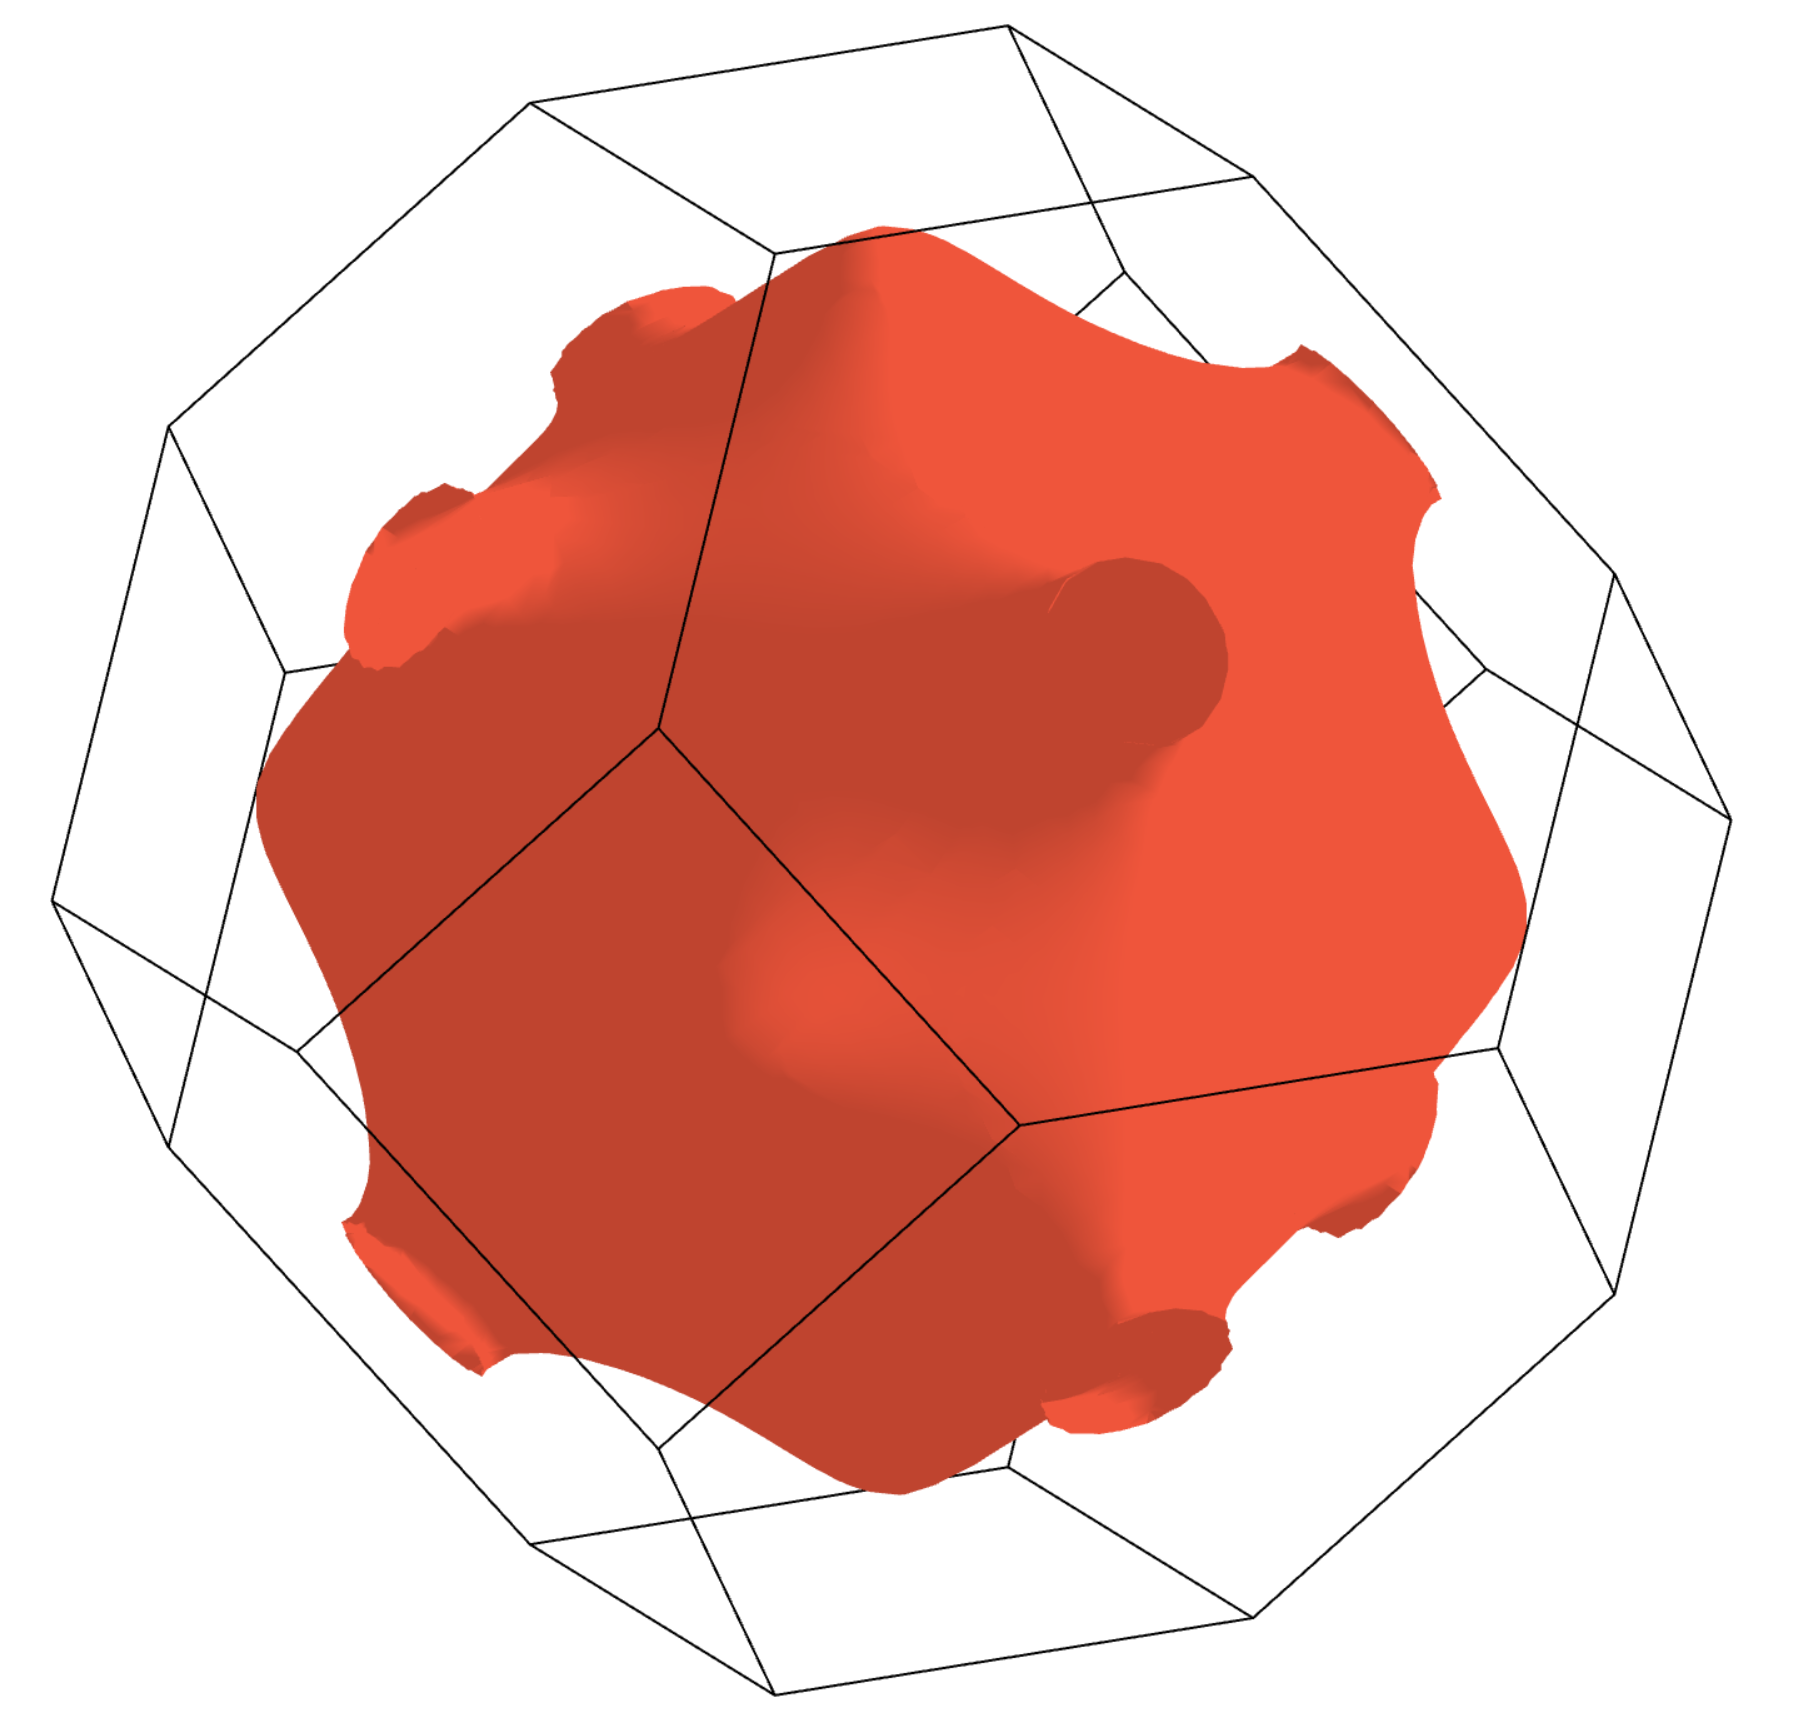
" width="500" />

The default settings target more complex shapes with meshes of better resolution. For simpler shapes (e.g. very few surface parts with holes) like with Au, it can be a good idea to introduce different colors for the front and back of the surface for better visibility. Since the performed exciting calculation for this tutorial is very rough, one might also want to smooth the surface.

In [ ]:
!fsvisual run_tutorial_fermi_surface/FERMISURF.bxsf -tcs -s 2

Here, the `-tcs` flag activates the two colored surface (tcs) and the `-s` smoothes the Fermi surface with a subdivision surface algorithm, which is applied twice (2). The newly created visualization provides a better perception of depth in a 2D image:

<img src="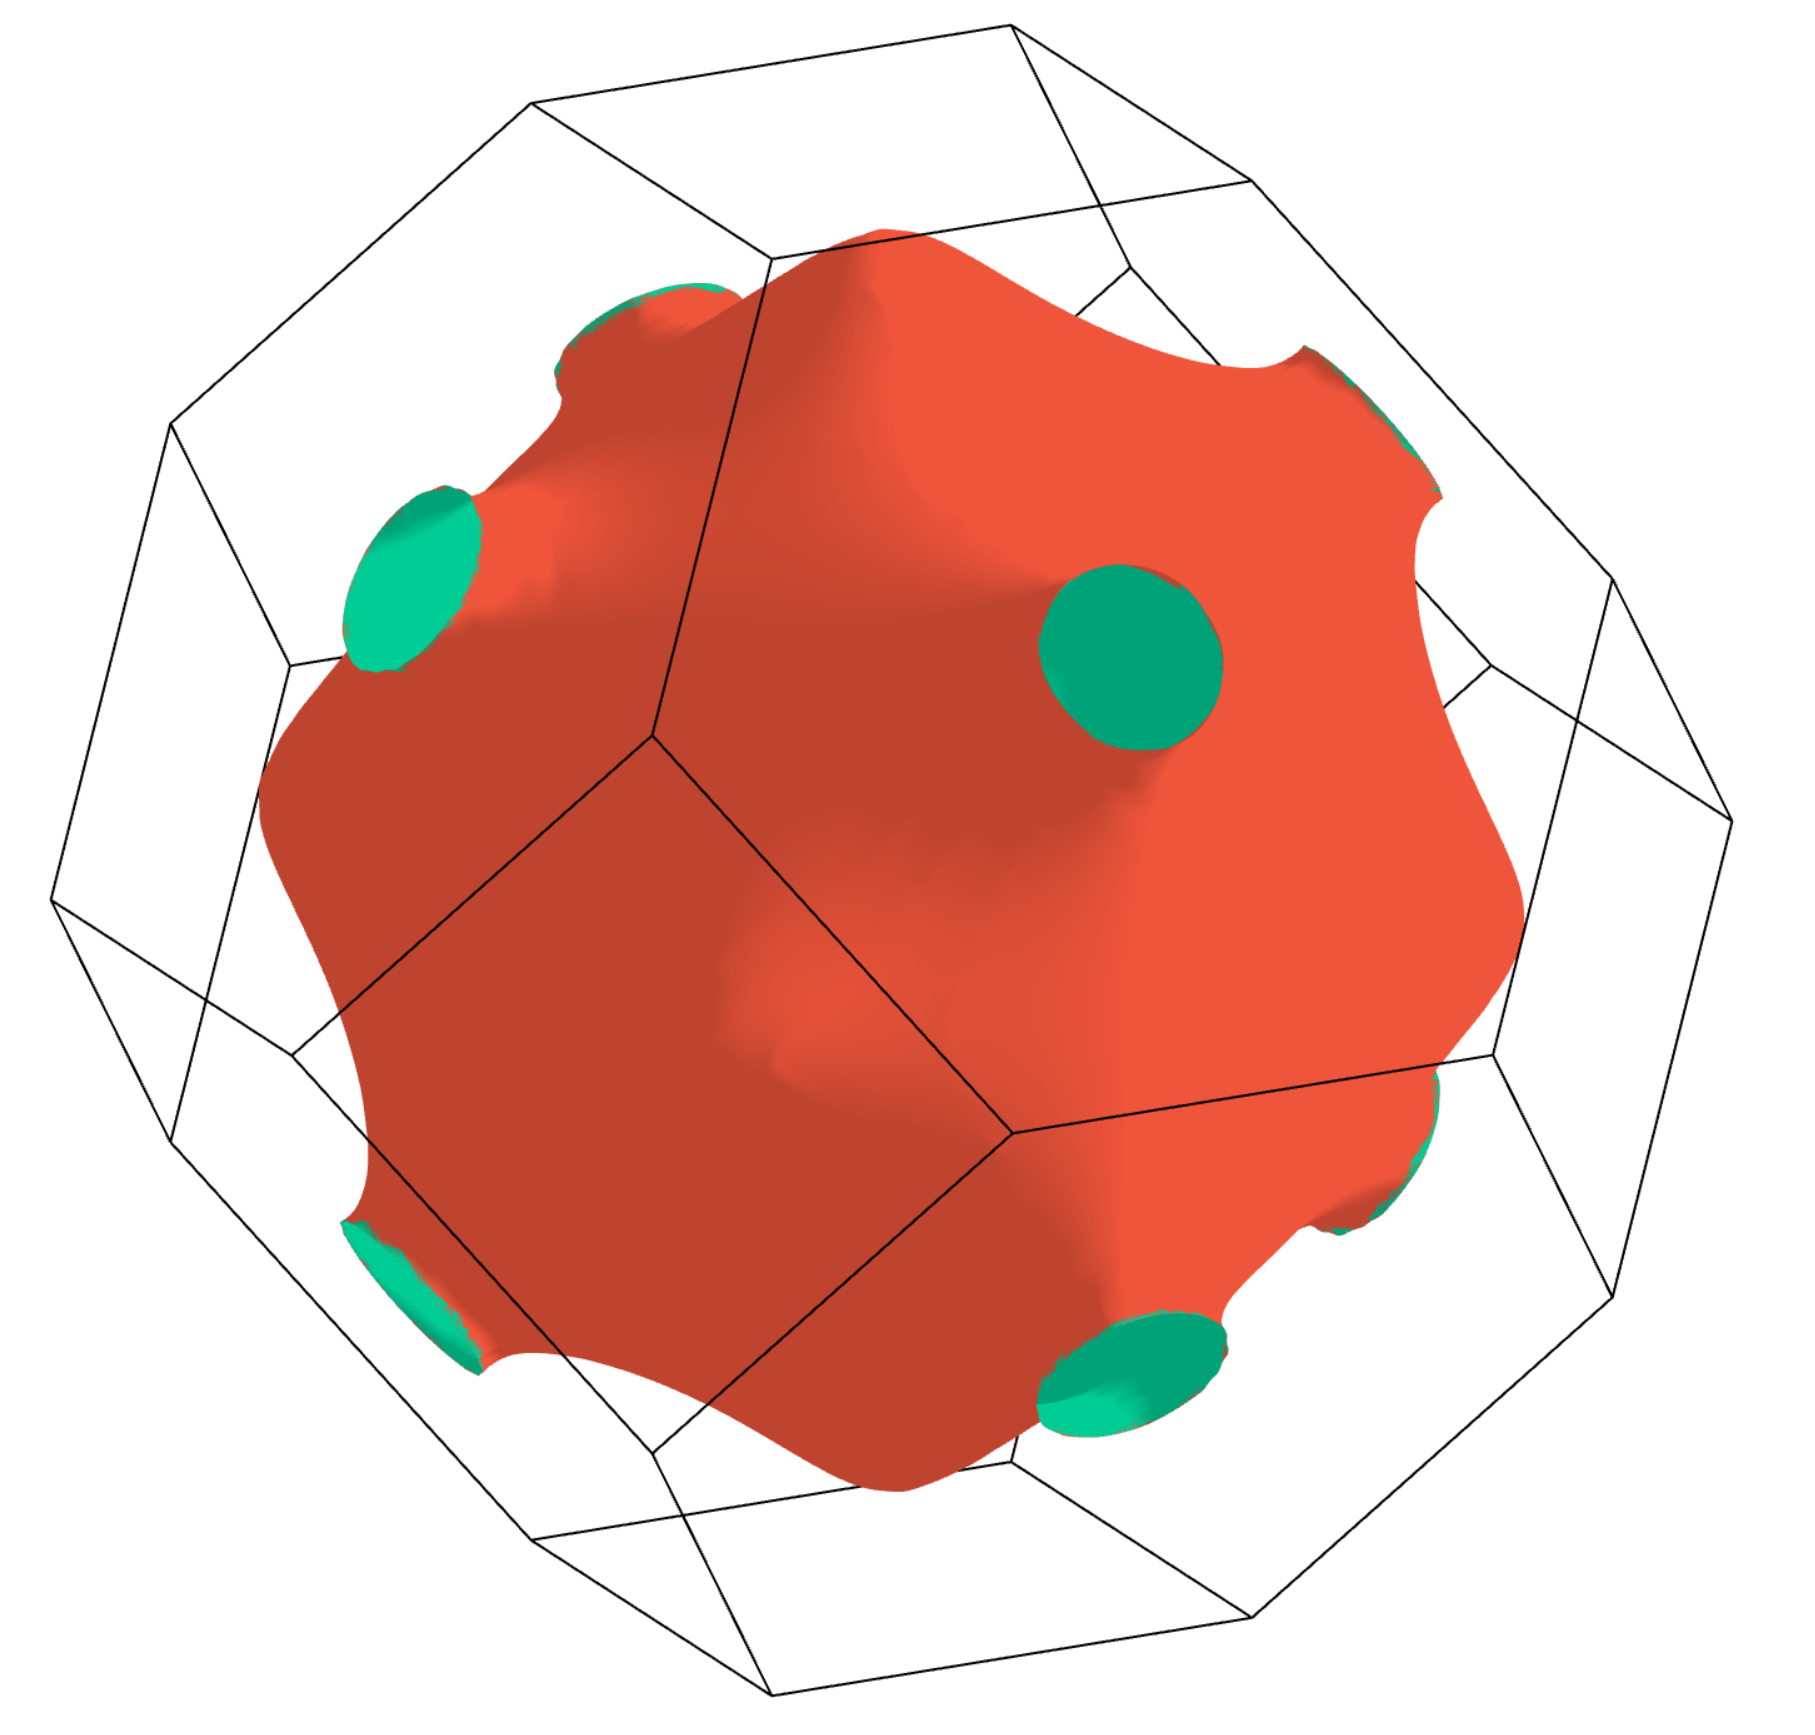
" width="500" />

The green artifacts on the edges are due to the low resolution of the Fermi surface data. The chosen 40x40x40 k-grid has too few data points for a high quality image.

<hr style="border:1px solid #DDD"> </hr>
<details>
    
<summary><strong><span style="color:firebrick"> How to visualize bxsf files using FSvisual</span></strong></summary>
    
The visualization of **bxsf** files with **FSvisual** differs with respect to that of **xsf** files. In fact, the **bxsf** format is specifically designed to visualize Fermi surfaces as a **bandgrid**, which is printed in the file. Further details about this file format can be found **[here](http://www.xcrysden.org/doc/XSF.html#bxsf)**.

It is also worth noting that, for convenience, in the exciting output **FERMISURF.bxsf** all energies are already shifted by the Fermi energy, so the default Fermi energy in **FSvisual** is set to **0.0**.

*However, this default Fermi energy value can be changed through an argument. To see all available arguments and flags for **FSvisual**, one can type `fsvisual --help` into the console!*

In the visualization window, there is a legend with an entry for each band. By clicking on a band in the legend one can either **<span style="color:green">activate</span>** or **<span style="color:red">deactivate</span>** the corresponding Fermi surface part in the visualization. By clicking and moving the mouse on the visualization window, one can rotate the **BZ**.

</details>
<hr style="border:1px solid #DDD"> </hr>

With a high-resolution Fermi surface calculation of the same material (Download link to NOMAD: [Au.bxsf](https://nomad-lab.eu/prod/v1/gui/search/entries/entry/id/aqJU0JUsLcfXo2XC7GRTXoD0yyK4/files/FS-Au-PBEsol.bxsf)), the visualization looks significantly smoother:

<img src="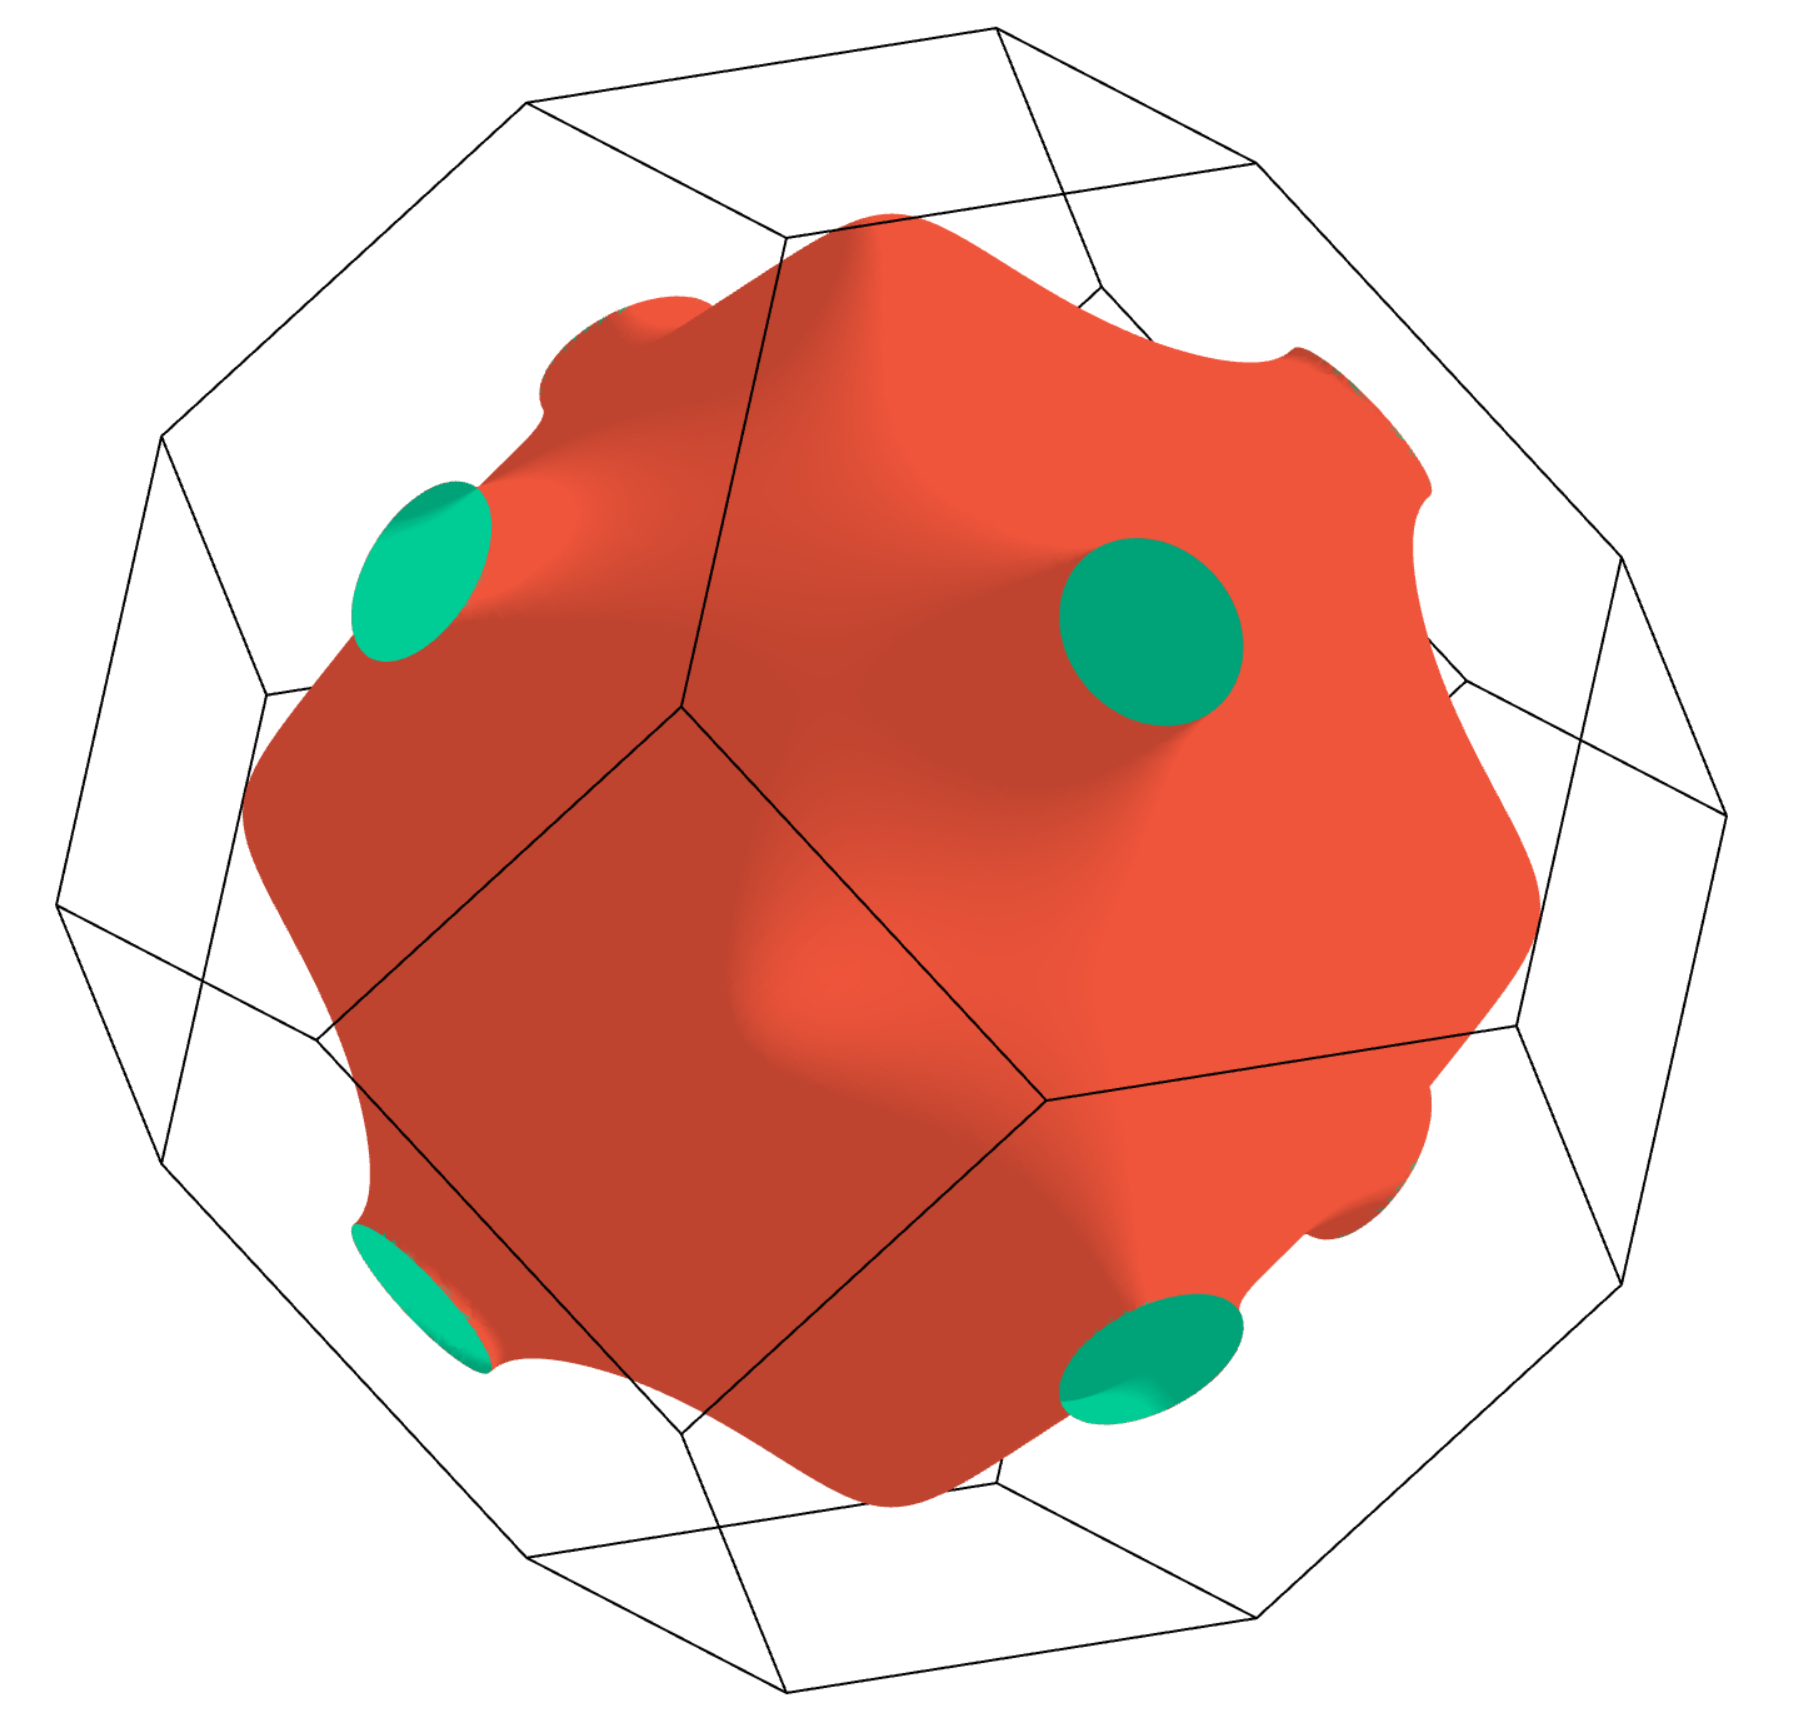
" width="500" />

<a id='2'></a>
#### <span style="color:green">Exercise</span>

- Plot the Fermi surface for **<span style="color:green">silver</span>** and **<span style="color:green">aluminum</span>**. How many bands contribute to the Fermi surface for **<span style="color:green">Ag</span>**? How many for **<span style="color:green">Al</span>**?

<hr style="border:2px solid #DDD"> </hr>